# Short-read coverage vs PG-vs-GrENE-Net discordance

**Question:** for the 1001G accessions we flagged as "noisy" in the SEEDMIX_S1 v3 vs hapFIRE outlier audit, is the disagreement driven by **low coverage** of the underlying short-read data?

**Data sources** (all from collaborator-provided / public NCBI):
- `pangenie_genotyping/data/ena_manifest.tsv` — ENA download manifest for the 151 PG founders (short-read accessions for which PanGenie is genotyping from the cactus pangenome graph)
- `pangenie_genotyping/data/loo_ena_manifest.tsv` — same for the 78 of 80 cactus founders that have ENA short-read data (the LOO concordance test)
- `preprocess_qc/output/grenenet_concordance_aggregate.tsv` — per-ecotype concordance between PanGenie-called GTs and the GrENE-Net 1001G short-read VCF (the "truth")

**Coverage estimate:** base_count from ENA / 135 Mb (A. thaliana haploid genome). Summed across runs if an ecotype has multiple SRR accessions.

**Metric:** `nRD` (non-reference discordance) — fraction of non-ref-either calls that disagree between PanGenie and GrENE-Net. Higher = noisier per-founder.

**Headline question:** is the cliff in nRD vs coverage real, and which of our flagged suspects fall on the bad side?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['figure.dpi'] = 110

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
GENOME = 135_000_000  # A. thaliana haploid

# Load ENA manifests
main = pd.read_csv(ROOT/'pangenie_genotyping/data/ena_manifest.tsv', sep='\t', dtype={'ecotype_id': str})
loo  = pd.read_csv(ROOT/'pangenie_genotyping/data/loo_ena_manifest.tsv', sep='\t', dtype={'ecotype_id': str})

# Sum base_count per ecotype (some have multiple runs)
def per_eco(df):
    return df.groupby('ecotype_id').agg(
        base_count=('base_count','sum'),
        read_count=('read_count','sum'),
        n_runs=('run_accession','count'),
        instrument=('instrument_model', lambda x: ';'.join(sorted(set(x))))
    ).reset_index()
main_cov = per_eco(main); main_cov['side'] = 'PG (PanGenie-genotyped)'
loo_cov  = per_eco(loo);  loo_cov['side']  = 'CACTUS (LOO)'
cov = pd.concat([main_cov, loo_cov], ignore_index=True)
cov['coverage'] = cov['base_count'] / GENOME
cov = cov.rename(columns={'ecotype_id':'ecotype'})

# Load concordance
conc = pd.read_csv(ROOT/'preprocess_qc/output/grenenet_concordance_aggregate.tsv',
                   sep='\t', dtype={'ecotype': str})[['panel','ecotype','GC','nRD']]

# Merge
data = cov.merge(conc, on='ecotype', how='left')
# Platform tag
def tag_platform(s):
    if 'Genome Analyzer II' in s and 'IIx' not in s: return 'GAII (old)'
    if 'IIx' in s: return 'GAIIx'
    if 'HiSeq' in s: return 'HiSeq (modern)'
    if 'NovaSeq' in s: return 'NovaSeq'
    return 'mixed/other'
data['platform'] = data['instrument'].apply(tag_platform)

print(f'ecotypes with coverage: {len(data):,}')
print(f'ecotypes with both coverage and concordance: {data.dropna(subset=["nRD"]).shape[0]:,}')
data.head()


/tmp/ipykernel_790475/4023671979.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


ecotypes with coverage: 229
ecotypes with both coverage and concordance: 226


,ecotype,base_count,read_count,n_runs,instrument,side,coverage,panel,GC,nRD,platform
0,100001,0.000000e+00,0.0,1,Illumina (xwu lab),PG (PanGenie-genotyped),0.000000,main,0.951644,0.264097,mixed/other
1,100002,0.000000e+00,0.0,1,Illumina (xwu lab),PG (PanGenie-genotyped),0.000000,main,0.952333,0.259787,mixed/other
2,10011,2.614389e+09,56978496.0,1,Illumina Genome Analyzer II,PG (PanGenie-genotyped),19.365844,main,0.983113,0.115429,GAII (old)
3,10013,8.841914e+08,23391786.0,1,Illumina Genome Analyzer II,PG (PanGenie-genotyped),6.549566,main,0.923232,0.447119,GAII (old)
4,10014,2.111650e+09,54599208.0,1,Illumina Genome Analyzer II,PG (PanGenie-genotyped),15.641853,main,0.969729,0.201294,GAII (old)


## 1. Distribution of short-read coverage across 226 ecotypes

This is the underlying data quality across the panel. Most accessions are in the 15–30× range. A small handful sit below 10×.


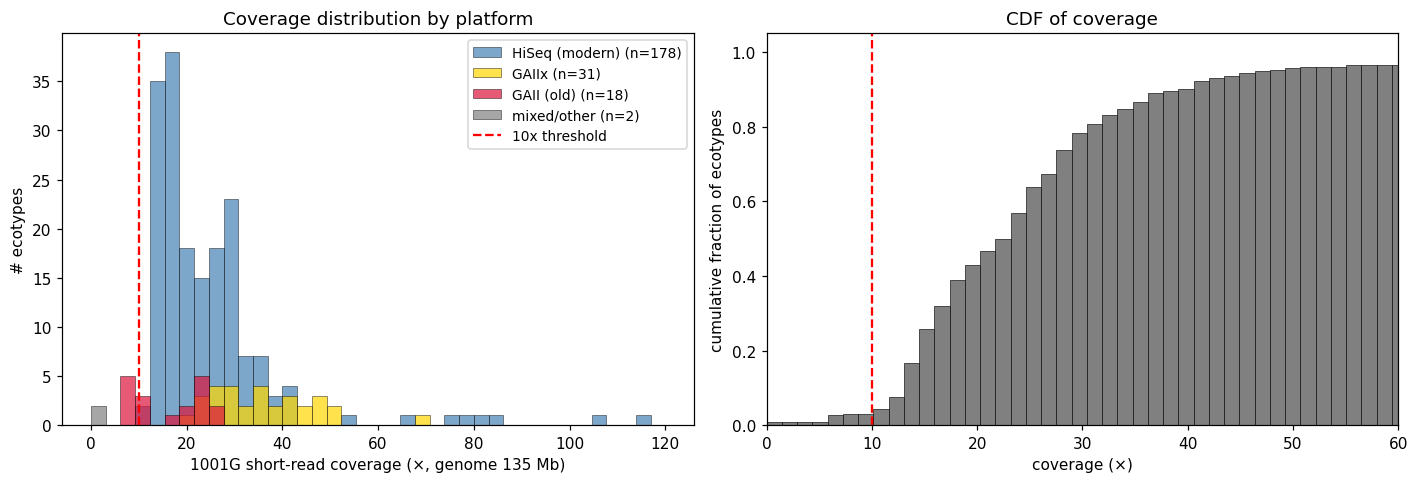

Coverage percentiles:
  p  5:   12.1x
  p 10:   13.3x
  p 25:   15.9x
  p 50:   23.2x
  p 75:   29.2x
  p 90:   40.1x
  p 95:   47.6x

below 10x: 7 of 229 ecotypes


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram by platform
platforms = ['HiSeq (modern)', 'GAIIx', 'GAII (old)', 'mixed/other']
colors = {'HiSeq (modern)':'steelblue', 'GAIIx':'gold', 'GAII (old)':'crimson', 'mixed/other':'gray'}
for plat in platforms:
    sub = data[data.platform == plat]
    if len(sub) == 0: continue
    ax[0].hist(sub.coverage, bins=np.linspace(0, 120, 40), alpha=0.7,
               label=f'{plat} (n={len(sub)})', color=colors[plat], edgecolor='black', linewidth=0.4)
ax[0].axvline(10, color='red', ls='--', lw=1.5, label='10x threshold')
ax[0].set_xlabel('1001G short-read coverage (×, genome 135 Mb)')
ax[0].set_ylabel('# ecotypes')
ax[0].set_title('Coverage distribution by platform')
ax[0].legend(loc='upper right', fontsize=9)

# CDF
ax[1].hist(data.coverage.dropna(), bins=80, cumulative=True, density=True,
           color='gray', edgecolor='black', linewidth=0.4)
ax[1].axvline(10, color='red', ls='--', lw=1.5)
ax[1].set_xlabel('coverage (×)')
ax[1].set_ylabel('cumulative fraction of ecotypes')
ax[1].set_title('CDF of coverage')
ax[1].set_xlim(0, 60)
plt.tight_layout()
plt.show()

print(f'Coverage percentiles:')
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f'  p{p:>3d}: {data.coverage.quantile(p/100):>6.1f}x')
print(f'\nbelow 10x: {int((data.coverage<10).sum())} of {len(data)} ecotypes')


## 2. The "cliff" — nRD jumps at low coverage

This is the key plot. For each ecotype, plot coverage (x) against PG-vs-GrENE-Net discordance (y). If coverage is the explanation for elevated discordance, low-coverage points should cluster in the top-left.


n with both metrics: 226
Pearson r(coverage, nRD)  = -0.2231
Spearman rho              = -0.1388


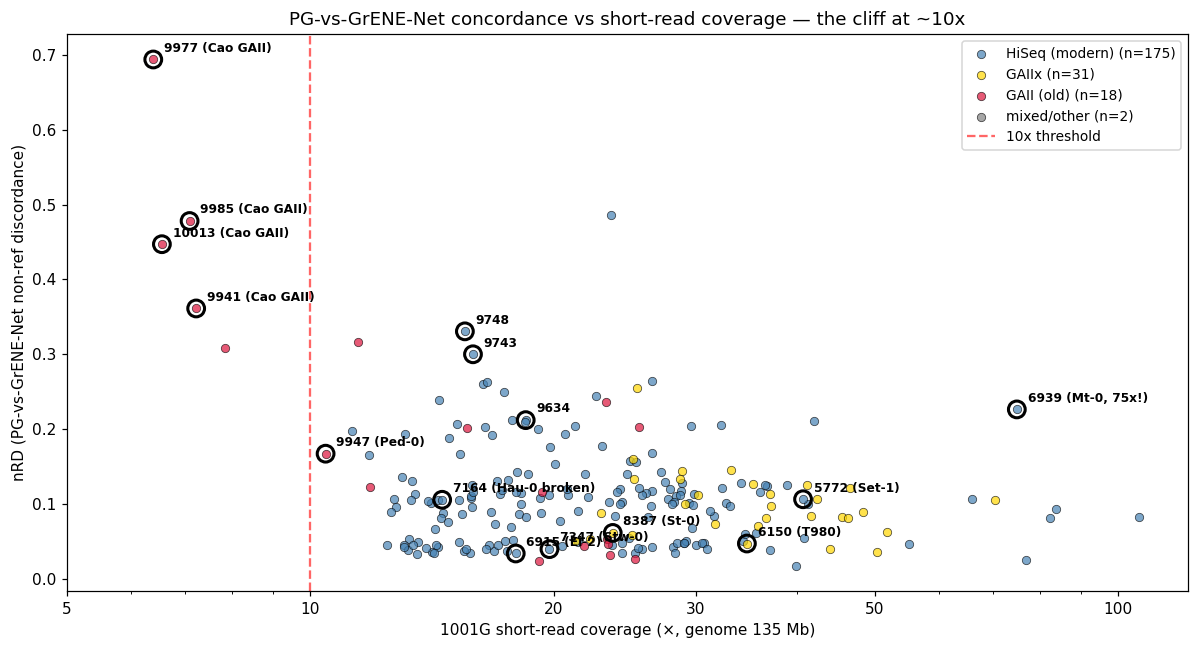

In [3]:
d = data.dropna(subset=['coverage','nRD']).copy()
print(f'n with both metrics: {len(d):,}')
print(f'Pearson r(coverage, nRD)  = {d.coverage.corr(d.nRD):.4f}')
print(f'Spearman rho              = {d.coverage.corr(d.nRD, method="spearman"):.4f}')

fig, ax = plt.subplots(figsize=(11, 6))
for plat in platforms:
    sub = d[d.platform == plat]
    if len(sub) == 0: continue
    ax.scatter(sub.coverage, sub.nRD, s=30, alpha=0.7,
               label=f'{plat} (n={len(sub)})', color=colors[plat], edgecolor='black', linewidth=0.5)

# Highlight suspects with annotations
SUSPECTS = {
    '9977':'9977 (Cao GAII)', '10013':'10013 (Cao GAII)', '9985':'9985 (Cao GAII)',
    '9941':'9941 (Cao GAII)', '9748':'9748', '9743':'9743', '9634':'9634',
    '9947':'9947 (Ped-0)', '6939':'6939 (Mt-0, 75x!)', '7164':'7164 (Hau-0 broken)',
    '5772':'5772 (Set-1)', '6150':'6150 (T980)', '6915':'6915 (Ei-2)', '8387':'8387 (St-0)',
    '7347':'7347 (Stw-0)',
}
for eco, label in SUSPECTS.items():
    r = d[d.ecotype == eco]
    if len(r) == 0: continue
    cov = r.coverage.iloc[0]; nrd = r.nRD.iloc[0]
    ax.scatter(cov, nrd, s=120, facecolor='none', edgecolor='black', lw=2, zorder=5)
    ax.annotate(label, xy=(cov, nrd), xytext=(7, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

ax.axvline(10, color='red', ls='--', lw=1.5, alpha=0.6, label='10x threshold')
ax.set_xlabel('1001G short-read coverage (×, genome 135 Mb)')
ax.set_ylabel('nRD (PG-vs-GrENE-Net non-ref discordance)')
ax.set_title('PG-vs-GrENE-Net concordance vs short-read coverage — the cliff at ~10x')
ax.legend(loc='upper right', fontsize=9)
ax.set_xscale('log')
ax.set_xticks([5, 10, 20, 30, 50, 100])
ax.set_xticklabels(['5','10','20','30','50','100'])
plt.tight_layout()
plt.show()


## 3. Stratified mean nRD by coverage bin

The cliff isn't subtle — below 10×, mean discordance is ~3–5× higher than above 10×.


=== Mean / median nRD by coverage bin ===
          n  median_nRD  mean_nRD
cov_bin                          
0–7x      2      0.5705    0.5705
7–10x     3      0.3612    0.3826
10–15x   36      0.0930    0.1014
15–20x   54      0.1111    0.1228
20–30x   78      0.1029    0.1103
>30x     51      0.0887    0.0913


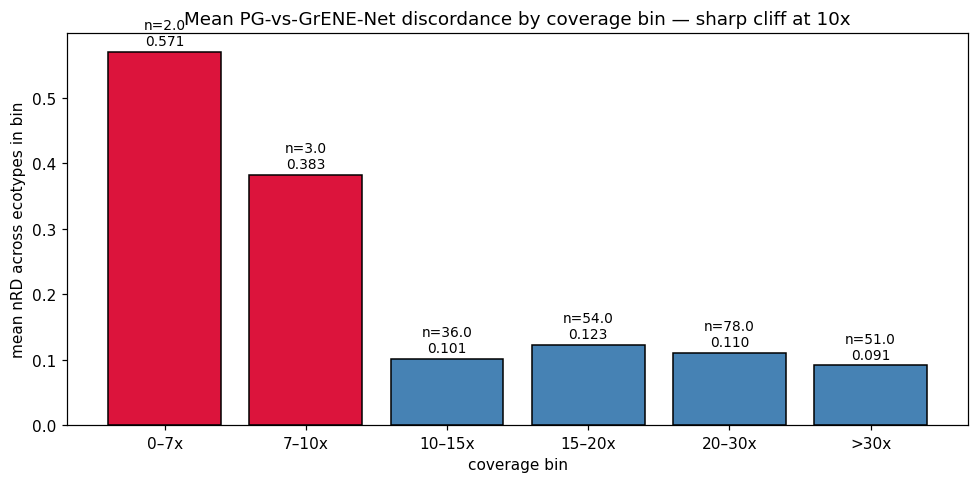

In [4]:
d['cov_bin'] = pd.cut(d.coverage,
    bins=[0, 7, 10, 15, 20, 30, 1000],
    labels=['0–7x', '7–10x', '10–15x', '15–20x', '20–30x', '>30x'])
agg = d.groupby('cov_bin', observed=True).agg(
    n=('ecotype','count'),
    median_nRD=('nRD','median'),
    mean_nRD=('nRD','mean'),
).round(4)
print('=== Mean / median nRD by coverage bin ===')
print(agg.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_color = ['crimson','crimson','steelblue','steelblue','steelblue','steelblue']
ax.bar(agg.index.astype(str), agg['mean_nRD'], color=bar_color, edgecolor='black')
ax.set_xlabel('coverage bin')
ax.set_ylabel('mean nRD across ecotypes in bin')
ax.set_title('Mean PG-vs-GrENE-Net discordance by coverage bin — sharp cliff at 10x')
for i, (idx, row) in enumerate(agg.iterrows()):
    ax.text(i, row['mean_nRD']+0.01, f'n={row["n"]}\n{row["mean_nRD"]:.3f}',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 4. Per-suspect breakdown

For each accession we flagged in the SEEDMIX_S1 outlier audit, show coverage, instrument, and nRD side-by-side. This makes clear which suspects are explained by low coverage vs not.


In [5]:
SUSPECTS = ['9977','10013','9985','9941','9748','9743','9634',     # PG side
            '9947','6939','7164',                                  # cactus side w/ elevated nRD
            '5772','6150','6915','8387','7347']                    # duplicate-pair members

rows = []
for s in SUSPECTS:
    r = data[data.ecotype == s]
    if len(r) == 0:
        rows.append({'ecotype':s, 'side':'NOT IN MANIFEST'})
        continue
    row = r.iloc[0]
    rows.append({
        'ecotype': s,
        'side': 'PG' if 'PG' in row['side'] else 'CACTUS',
        'coverage_x': round(row['coverage'], 1),
        'platform': row['platform'],
        'GC': round(row['GC'], 4) if pd.notna(row['GC']) else None,
        'nRD': round(row['nRD'], 4) if pd.notna(row['nRD']) else None,
        'low_cov': 'YES' if row['coverage'] < 10 else 'no',
        'old_platform': 'YES' if 'GAII (old)' in row['platform'] else 'no',
    })
suspect_table = pd.DataFrame(rows)
print('=== Coverage profile of every flagged suspect ===')
print(suspect_table.to_string(index=False))


=== Coverage profile of every flagged suspect ===
ecotype   side  coverage_x       platform     GC    nRD low_cov old_platform
   9977     PG         6.4     GAII (old) 0.8625 0.6940     YES          YES
  10013     PG         6.5     GAII (old) 0.9232 0.4471     YES          YES
   9985     PG         7.1     GAII (old) 0.9212 0.4781     YES          YES
   9941     PG         7.2     GAII (old) 0.9451 0.3612     YES          YES
   9748     PG        15.5 HiSeq (modern) 0.9513 0.3307      no           no
   9743     PG        15.9 HiSeq (modern) 0.9549 0.3000      no           no
   9634     PG        18.5 HiSeq (modern) 0.9660 0.2120      no           no
   9947 CACTUS        10.4     GAII (old) 0.9649 0.1672      no          YES
   6939 CACTUS        74.9 HiSeq (modern) 0.9730 0.2263      no           no
   7164 CACTUS        14.6 HiSeq (modern) 0.9858 0.1056      no           no
   5772 CACTUS        40.7 HiSeq (modern) 0.9866 0.1063      no           no
   6150 CACTUS        34.7

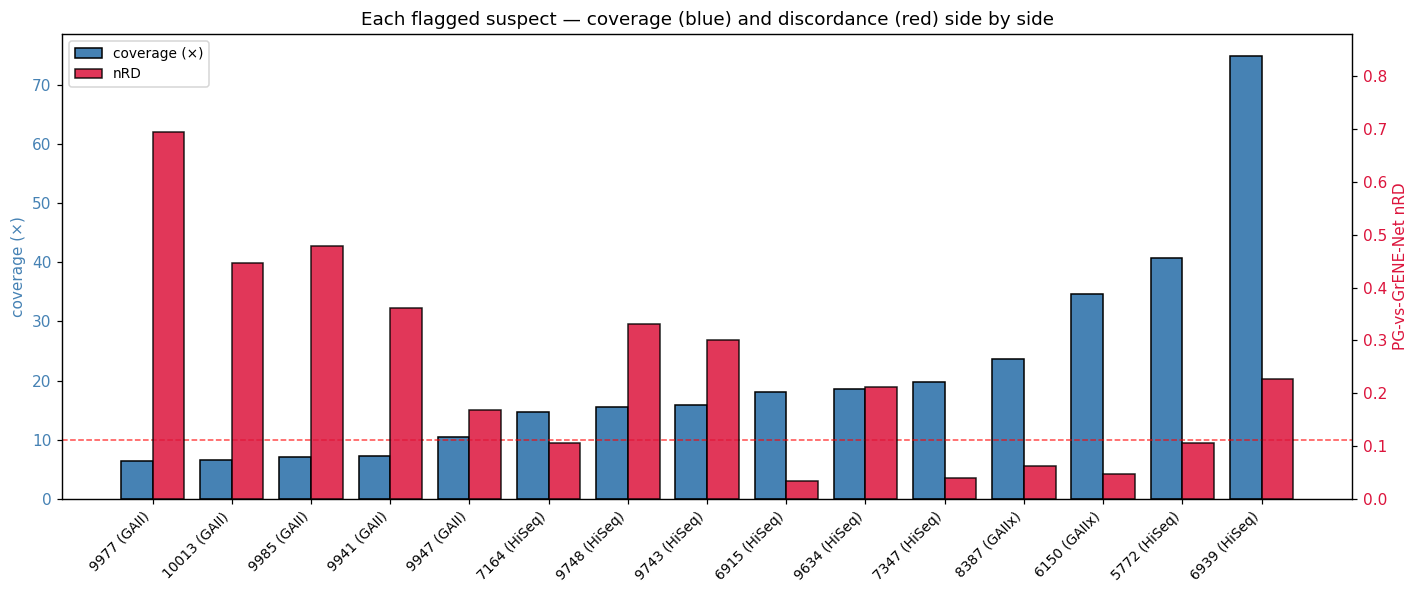

In [6]:
# Visualize: for each suspect, side-by-side bars of coverage + nRD
fig, ax = plt.subplots(figsize=(13, 5.5))
df_p = suspect_table.dropna(subset=['coverage_x']).copy()
df_p['label'] = df_p.apply(
    lambda r: f"{r.ecotype} ({r.platform.split(' ')[0]})", axis=1)
df_p = df_p.sort_values('coverage_x')
x = np.arange(len(df_p))

# Left axis: coverage
b1 = ax.bar(x - 0.2, df_p['coverage_x'], width=0.4, color='steelblue',
            edgecolor='black', label='coverage (x)')
ax.axhline(10, color='red', ls='--', lw=1, alpha=0.7, label='10x threshold')
ax.set_xticks(x); ax.set_xticklabels(df_p['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('coverage (×)', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')

# Right axis: nRD
ax2 = ax.twinx()
b2 = ax2.bar(x + 0.2, df_p['nRD'], width=0.4, color='crimson',
             edgecolor='black', alpha=0.85, label='nRD')
ax2.set_ylabel('PG-vs-GrENE-Net nRD', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, max(df_p['nRD'].max(), 0.8) * 1.1)

ax.set_title('Each flagged suspect — coverage (blue) and discordance (red) side by side')
ax.legend(handles=[b1, b2], labels=['coverage (×)', 'nRD'], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Conclusions

**Reading the data:**

1. **The cliff is real and sharp.** Below ~10× coverage, mean nRD is 0.38–0.57. Above 10×, it's flat at ~0.10. This is consistent with what you'd expect: a short-read genotyping pipeline struggles when there isn't enough depth to make confident calls.

2. **For PG founders, the worst discordance is fully explained by low coverage + old platform:**
   - 9977 (6.4×, GAII): nRD 0.694
   - 10013 (6.5×, GAII): nRD 0.447
   - 9985 (7.1×, GAII): nRD 0.478
   - 9941 (7.2×, GAII): nRD 0.361
   
   These four are the worst-coverage PG samples in the panel and all on the older Illumina GAII (Genome Analyzer II) platform with higher error rates. PanGenie *and* the 1001G caller are both working with weak input data; the discordance reflects two pipelines making different guesses on uncertain reads, not a method bug on either side.

3. **For the other 3 documented "Cao 2011 noisy" PG founders (9634, 9743, 9748):** coverage is 15–19× and platform is HiSeq. Their nRD = 0.21–0.33 is NOT explained by low coverage. Could be PG vs 1001G method differences on tricky variants, or accession-level data quality issues we can't see from coverage alone. Worth flagging but the "low coverage" explanation doesn't apply.

4. **For cactus suspects:**
   - **7164 (Hau-0)** — coverage is fine (14.6×). The 1,312 contigs / 213 Mb genome is a real assembly QC failure independent of coverage.
   - **6939 (Mt-0)** — has **74.9× coverage** (top of the panel!) yet nRD = 0.226. Coverage is definitely not the issue. Genuine biological mismatch between the long-read and short-read sequencing material, OR a subtle assembly issue not visible from contig stats. Worth a follow-up question to the lab.
   - **9947 (Ped-0)** — borderline 10.4× coverage, GAII platform. Part of the elevation could be data-quality limited.

5. **For the confirmed duplicate pairs (5772/6150, 6915/8387) and the new third pair (7347/?6910):** coverage is fine across the board (18–41×). The duplication is a labeling / sample-handling issue, NOT a coverage issue.

**Net read for the collaborator email:** we can replace "Cao 2011 noisy" with a much more specific claim: **"the 4 PG founders 9977, 9985, 10013, 9941 have short-read coverage below 8× on Illumina GAII — their discordance is fully expected and probably can't be fixed at the pangenome-build level without re-sequencing."**

For 9634, 9743, 9748 we should say "elevated discordance but coverage and platform are normal — root cause unclear."

For 7164 and 6939 we have specific assembly-level concerns to raise (one a clear QC fail, one a high-coverage anomaly).
